# The Similarity Theory Playground

This notebook is the research surface for exploring your core thesis:

- similar dynamical processes can replay across time
- they may replay across assets
- they may replay across timeframes
- the broader the data bank, the more interesting the analogs become

Use this notebook to:

- inspect what data is available
- run the engine directly from the local library
- optionally compare with the API output
- track whether the theory is producing convincing matches
- add financial model experiments later

In [2]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

NOTEBOOK_CWD = Path.cwd().resolve()
PLAYGROUND_ROOT = next(
    (path for path in [NOTEBOOK_CWD, *NOTEBOOK_CWD.parents] if (path / "playground.py").exists()),
    None,
)
if PLAYGROUND_ROOT is None:
    candidate = NOTEBOOK_CWD / "the-similarity-playground"
    if (candidate / "playground.py").exists():
        PLAYGROUND_ROOT = candidate
if PLAYGROUND_ROOT is None:
    raise ModuleNotFoundError("Could not locate playground.py from the current notebook working directory.")
if str(PLAYGROUND_ROOT) not in sys.path:
    sys.path.insert(0, str(PLAYGROUND_ROOT))

from playground import (
    APP_ROOT,
    API_ROOT,
    DATA_ROOT,
    ENGINE_ROOT,
    bootstrap_imports,
    forecast_summary_frame,
    load_manifest,
    make_api_payload_from_dataset,
    run_api_search,
    run_local_search,
    theory_scorecard,
    top_matches_frame,
)

bootstrap_imports()
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 50)

ROOT = PLAYGROUND_ROOT.parent
print("project root:", ROOT)
print("engine root:", ENGINE_ROOT)
print("data root:", DATA_ROOT)
print("api root:", API_ROOT)
print("app root:", APP_ROOT)

project root: /Users/buyantogtokh/Projects/14
engine root: /Users/buyantogtokh/Projects/14/the_similarity
data root: /Users/buyantogtokh/Projects/14/the-similarity-data
api root: /Users/buyantogtokh/Projects/14/the-similarity-api
app root: /Users/buyantogtokh/Projects/14/the-similarity-app


In [3]:
manifest = load_manifest()
manifest

,asset_class,symbol,timeframe,source,path,start_timestamp,end_timestamp,row_count,last_updated_at
0,commodities,gold,1d,stooq,data/commodities/gold/1d.parquet,2005-02-25T00:00:00+00:00,2026-03-06T00:00:00+00:00,5289,2026-03-07T08:59:06.099699+00:00
1,crypto,btc_usdt,1d,ccxt,data/crypto/btc_usdt/1d.parquet,2024-03-17T00:00:00+00:00,2026-03-07T00:00:00+00:00,721,2026-03-07T08:58:49.717367+00:00
2,crypto,btc_usdt,1h,ccxt,data/crypto/btc_usdt/1h.parquet,2026-02-05T08:00:00+00:00,2026-03-07T08:00:00+00:00,721,2026-03-07T08:58:44.782255+00:00
3,crypto,btc_usdt,1m,ccxt,data/crypto/btc_usdt/1m.parquet,2026-03-06T20:54:00+00:00,2026-03-07T08:58:00+00:00,725,2026-03-07T08:58:42.358956+00:00
4,crypto,btc_usdt,4h,ccxt,data/crypto/btc_usdt/4h.parquet,2025-11-07T08:00:00+00:00,2026-03-07T08:00:00+00:00,721,2026-03-07T08:58:47.201789+00:00
5,crypto,eth_usdt,1d,ccxt,data/crypto/eth_usdt/1d.parquet,2024-03-17T00:00:00+00:00,2026-03-07T00:00:00+00:00,721,2026-03-07T08:58:59.611327+00:00
6,crypto,eth_usdt,1h,ccxt,data/crypto/eth_usdt/1h.parquet,2026-02-05T08:00:00+00:00,2026-03-07T08:00:00+00:00,721,2026-03-07T08:58:54.751973+00:00
7,crypto,eth_usdt,1m,ccxt,data/crypto/eth_usdt/1m.parquet,2026-03-06T20:55:00+00:00,2026-03-07T08:58:00+00:00,724,2026-03-07T08:58:52.218797+00:00
8,crypto,eth_usdt,4h,ccxt,data/crypto/eth_usdt/4h.parquet,2025-11-07T08:00:00+00:00,2026-03-07T08:00:00+00:00,721,2026-03-07T08:58:57.171245+00:00
9,forex,eurusd,1d,twelvedata,data/forex/eurusd/1d.parquet,2007-01-25T00:00:00+00:00,2026-03-07T00:00:00+00:00,5000,2026-03-07T08:59:04.662340+00:00


In [4]:
asset_class = "crypto"
symbol = "btc_usdt"
timeframe = "1h"
window_size = 120
top_k = 10
stride = 5
forward_bars = 30
end_offset = 0

print({
    "asset_class": asset_class,
    "symbol": symbol,
    "timeframe": timeframe,
    "window_size": window_size,
    "top_k": top_k,
    "stride": stride,
    "forward_bars": forward_bars,
    "end_offset": end_offset,
})

{'asset_class': 'crypto', 'symbol': 'btc_usdt', 'timeframe': '1h', 'window_size': 120, 'top_k': 10, 'stride': 5, 'forward_bars': 30, 'end_offset': 0}


In [7]:
local_run = run_local_search(
    asset_class,
    symbol,
    timeframe,
    window_size=window_size,
    top_k=top_k,
    stride=stride,
    end_offset=end_offset,
    forward_bars=forward_bars,
)

history_frame = local_run["history_frame"]
query_frame = local_run["query_frame"]
results = local_run["results"]
forecast = local_run["forecast"]

scorecard = theory_scorecard(results, forecast)
scorecard

{'match_count': 10.0,
 'best_confidence': 9.459209748283834,
 'best_dtw': 0.9230835563688793,
 'best_pearson': 0.5995249707403361,
 'forecast_p10_terminal': -0.04324225779513303,
 'forecast_p50_terminal': 0.01453524463996956,
 'forecast_p90_terminal': 0.06452981964878259}

In [8]:
matches_df = top_matches_frame(results)
forecast_df = forecast_summary_frame(forecast)

print("Top matches")
display(matches_df.head(10))

print("Forecast summary")
display(forecast_df)

Top matches


,start_idx,end_idx,start_date,end_date,confidence_score,dtw,pearson
0,280,400,2026-02-17T00:00:00.000000000,2026-02-21T23:00:00.000000000,9.459210,0.923084,0.599525
1,25,145,2026-02-06T09:00:00.000000000,2026-02-11T08:00:00.000000000,9.405055,0.933893,0.573560
2,60,180,2026-02-07T20:00:00.000000000,2026-02-12T19:00:00.000000000,9.370482,0.928868,0.573681
3,425,545,2026-02-23T01:00:00.000000000,2026-02-28T00:00:00.000000000,9.365159,0.937017,0.561208
4,340,460,2026-02-19T12:00:00.000000000,2026-02-24T11:00:00.000000000,9.359953,0.922247,0.580845
5,165,285,2026-02-12T05:00:00.000000000,2026-02-17T04:00:00.000000000,9.348958,0.925339,0.574317
6,70,190,2026-02-08T06:00:00.000000000,2026-02-13T05:00:00.000000000,9.348873,0.932078,0.564866
7,20,140,2026-02-06T04:00:00.000000000,2026-02-11T03:00:00.000000000,9.347394,0.929163,0.568651
8,415,535,2026-02-22T15:00:00.000000000,2026-02-27T14:00:00.000000000,9.346483,0.929292,0.568288
9,210,330,2026-02-14T02:00:00.000000000,2026-02-19T01:00:00.000000000,9.313622,0.925205,0.567438


Forecast summary


,percentile,terminal_return,bars
0,10,-0.043242,30
1,50,0.014535,30
2,90,0.064530,30


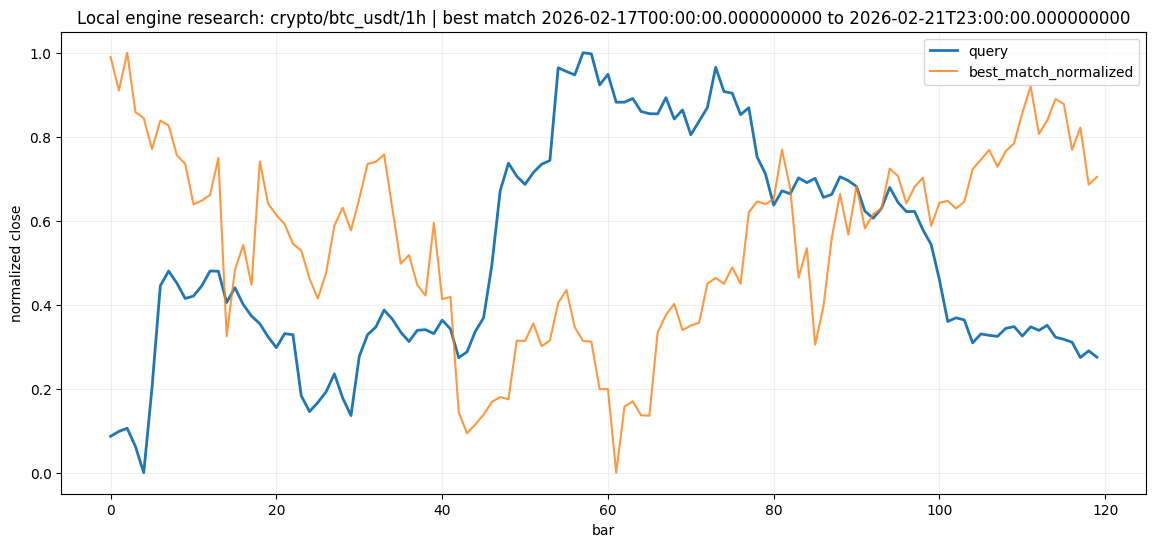

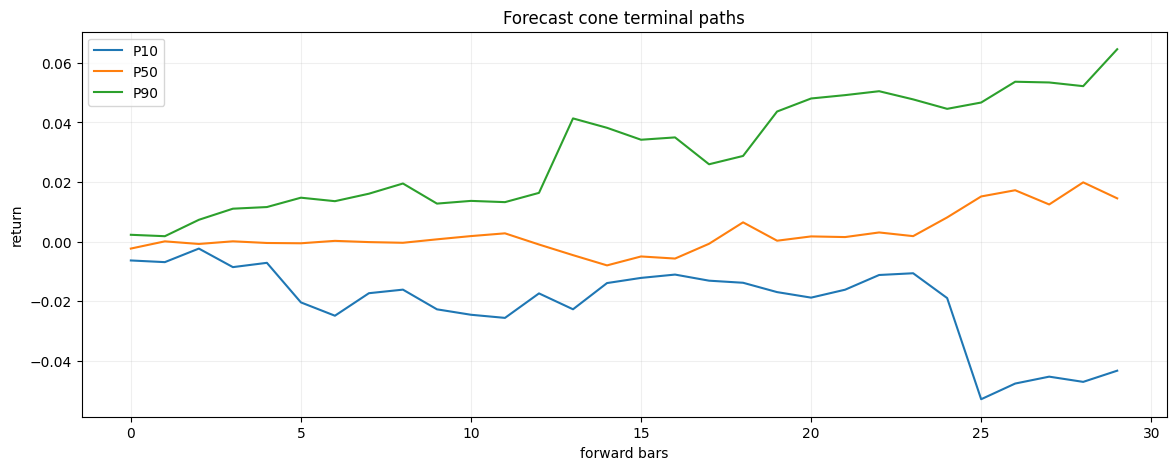

In [10]:
best_match = results.best
fig, ax = plt.subplots(figsize=(14, 6))

query_values = query_frame["close"].reset_index(drop=True)
query_norm = (query_values - query_values.min()) / max(query_values.max() - query_values.min(), 1e-9)
bar_index = range(len(query_norm))

ax.plot(bar_index, query_norm, label="query", linewidth=2)

if best_match is not None and best_match.matched_series is not None:
    match_values = pd.Series(best_match.matched_series).reset_index(drop=True)
    match_norm = (match_values - match_values.min()) / max(match_values.max() - match_values.min(), 1e-9)
    ax.plot(bar_index, match_norm, label="best_match_normalized", alpha=0.8)
    ax.set_title(
        f"Local engine research: {asset_class}/{symbol}/{timeframe} | "
        f"best match {best_match.start_date} to {best_match.end_date}"
    )
else:
    ax.set_title(f"Local engine research: {asset_class}/{symbol}/{timeframe}")

ax.set_xlabel("bar")
ax.set_ylabel("normalized close")
ax.legend()
ax.grid(alpha=0.2)
plt.show()

fig, ax = plt.subplots(figsize=(14, 5))
for percentile, curve in sorted(forecast.curves.items()):
    ax.plot(curve, label=f"P{percentile}")
ax.set_title("Forecast cone terminal paths")
ax.set_xlabel("forward bars")
ax.set_ylabel("return")
ax.legend()
ax.grid(alpha=0.2)
plt.show()

In [12]:
api_payload = make_api_payload_from_dataset(
    asset_class,
    symbol,
    timeframe,
    window_size=window_size,
    top_k=top_k,
    stride=stride,
    end_offset=end_offset,
    forward_bars=forward_bars,
)

try:
    api_response = run_api_search(api_payload)
    print("API matches:", len(api_response["matches"]))
    print("API forecast bars:", api_response["forecast"]["bars"])
    display(pd.DataFrame(api_response["matches"]).head())
except Exception as error:
    print("API call failed. Start the API with ./dev.sh backend or ./dev.sh full.")
    print(error)

API matches: 10
API forecast bars: 30


,startIdx,endIdx,startDate,endDate,confidenceScore,scoreBreakdown,matchedSeries,transformAlpha,transformBeta,transformR2,koopmanEigenvalues,fractalSpectrum,persistenceDiagram,forwardWindow
0,600,720,None,None,10.071236,"{'bempedelisR2': 0.0, 'bempedelisSmoothness': ...","[66281.9, 66177.3, 66272.9, 66334.6, 65977.5, ...",None,None,0.0,None,None,None,None
1,595,715,None,None,9.855647,"{'bempedelisR2': 0.0, 'bempedelisSmoothness': ...","[66803.9, 66815.9, 66693.5, 66218.9, 66006.4, ...",None,None,0.0,None,None,None,None
2,560,680,None,None,9.507990,"{'bempedelisR2': 0.0, 'bempedelisSmoothness': ...","[65131.4, 65449.9, 65885.8, 66359.2, 66948.6, ...",None,None,0.0,None,None,None,None
3,280,400,None,None,9.459210,"{'bempedelisR2': 0.0, 'bempedelisSmoothness': ...","[68870.7, 68632.1, 68900.6, 68478.3, 68434.9, ...",None,None,0.0,None,None,None,None
4,580,700,None,None,9.421681,"{'bempedelisR2': 0.0, 'bempedelisSmoothness': ...","[66320.9, 66940.0, 66856.7, 66839.8, 66188.3, ...",None,None,0.0,None,None,None,None


## Financial Models Sandbox

This section is intentionally a placeholder for later work.

Ideas to add here:

- regime models
- factor overlays
- risk models
- portfolio construction logic
- position sizing experiments
- backtest diagnostics against match quality